In [42]:
# imports
!pip install pandas
!pip install matplotlib
!pip install graphviz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, classification_report
import graphviz  


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import pandas as pd
df = pd.read_csv("OnlineRetail.csv", encoding="latin1")
df.head(10)
#right now every row is one purchased item so we have to make it one row per customer with groupby

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01-12-2010 08:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01-12-2010 08:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,01-12-2010 08:34,1.69,13047.0,United Kingdom


In [44]:
#data cleaning
df.describe() #summary of data characteristics so we can see scale of numerics
#quantity has neg values so in invoice orders were returned

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [45]:
#data types and missing values
print(df.dtypes) # tells us data types so we know if any need to be changed
df.isna().sum() # checks for missing values and tells us how many if any

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## EDA
***target variable: how is purchase amount distributed across customers?***

In [46]:
# drop rows with no customer id cause 135080 missing
df = df.dropna(subset=["CustomerID"])

#df.describe showed negative quantities os are canceeld in data, canceld orders ahve annvoice # that starts with C
df = df[df['InvoiceNo'].astype(str).str.startswith('C') == False] # only keeps rows where invoice does not start with C

# remove negative and 0 values from quantity and unitprice as per df.describe
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

#gotta change date to datetime so python can use it to do time based calculations
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

# we can create a new column for total price of each item by multiplying quantity and unit price so we can determine customer max purchase and spending
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print(df.shape)
df.head()

(397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


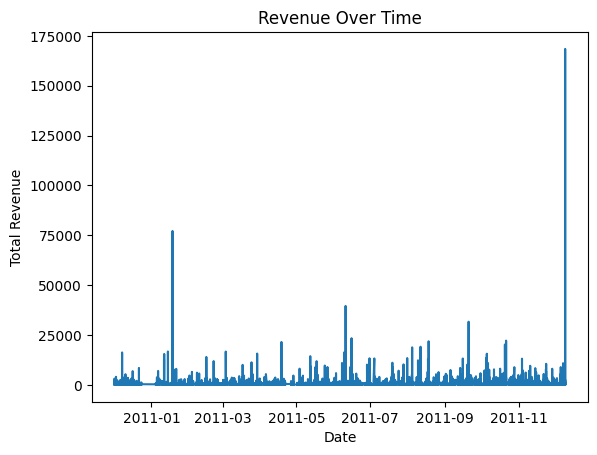

In [47]:
# revenue change over time
revenue = df.groupby('InvoiceDate')['TotalPrice'].sum()
plt.plot(revenue)
plt.title('Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.show()

C:\Users\sfita\AppData\Local\Temp\ipykernel_43264\219785649.py:4: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  top_countries.plot(kind="bar")


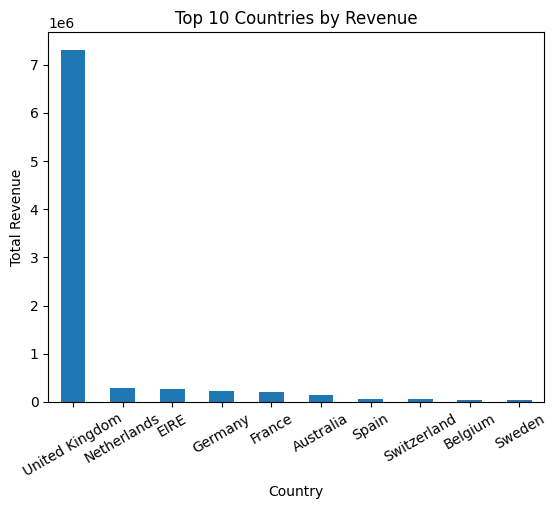

In [48]:
# check for which countries tend to generate the most revenue
top_countries = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
top_countries = top_countries.head(10)
top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.show()

In [49]:
# we collapse each item row to become a row per customer with all features - so now customer based features instead of item based features
df_customers = df.groupby('CustomerID').agg(
    TotalSpent    = ('TotalPrice', 'sum'),
    Frequency     = ('InvoiceNo',  'nunique'),
    Avg_OrderValue = ('TotalPrice', 'mean'),
    Avg_Quantity   = ('Quantity',   'mean'),
    Avg_UnitPrice  = ('UnitPrice',  'mean')
).reset_index()

df_customers.head()

,CustomerID,TotalSpent,Frequency,Avg_OrderValue,Avg_Quantity,Avg_UnitPrice
0,12346.0,77183.60,1,77183.600000,74215.000000,1.040000
1,12347.0,4310.00,7,23.681319,13.505495,2.644011
2,12348.0,1797.24,4,57.975484,75.516129,5.764839
3,12349.0,1757.55,1,24.076027,8.643836,8.289041
4,12350.0,334.40,1,19.670588,11.588235,3.841176


In [50]:
# check data types of customer df
print(df_customers.dtypes)

CustomerID        float64
TotalSpent        float64
Frequency           int64
Avg_OrderValue    float64
Avg_Quantity      float64
Avg_UnitPrice     float64
dtype: object


The plot reveals that the UK pred to other nationsking up a large part of the data. So when predicting if an individual is a high spender we'll ideally be dealing with the UK demographic. So instaed of focuing we have to focus on customer spending

C:\Users\sfita\AppData\Local\Temp\ipykernel_43264\1919750208.py:3: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df_customers['TotalSpent'].plot(kind='hist', bins=50)
C:\Users\sfita\AppData\Local\Temp\ipykernel_43264\1919750208.py:3: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df_customers['TotalSpent'].plot(kind='hist', bins=50)


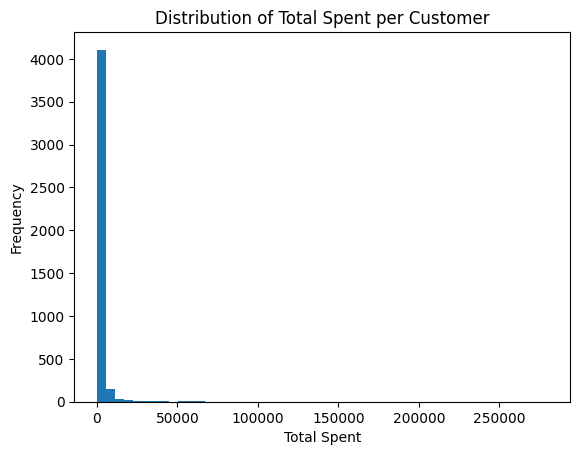

In [51]:
#EDA on new df on customer rows
# how is total spend distributed across customers?
df_customers['TotalSpent'].plot(kind='hist', bins=50)
plt.title('Distribution of Total Spent per Customer')
plt.xlabel('Total Spent')
plt.show()

C:\Users\sfita\AppData\Local\Temp\ipykernel_43264\4056734560.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df_customers['Frequency'].plot(kind='hist', bins=50)
C:\Users\sfita\AppData\Local\Temp\ipykernel_43264\4056734560.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df_customers['Frequency'].plot(kind='hist', bins=50)


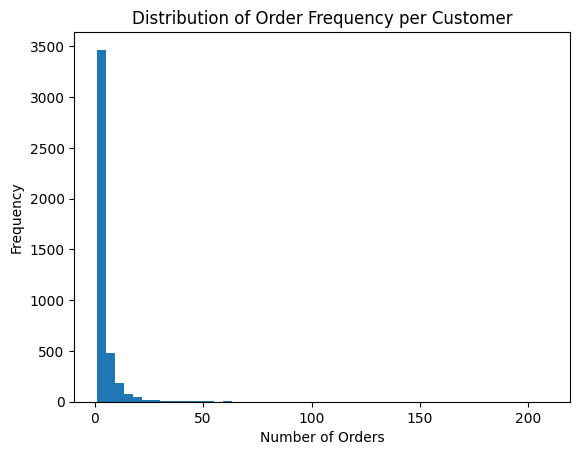

In [52]:
# how many orders do customers typically place?
df_customers['Frequency'].plot(kind='hist', bins=50)
plt.title('Distribution of Order Frequency per Customer')
plt.xlabel('Number of Orders')
plt.show()

In [62]:
#our question: Can we predict whether a customer is a high spender based on their purchasing patterns?
#target variable: high spender or not (can define as spending more than 75th percentile of total spend)
threshold = df_customers['TotalSpent'].quantile(0.75)
df_customers['HighSpender'] = (df_customers['TotalSpent'] > threshold).astype(int)
print(df_customers['HighSpender'].value_counts())

HighSpender
0    3253
1    1085
Name: count, dtype: int64


In [54]:
#prevalence of high spenders in our data
highspender_prev = df_customers['HighSpender'].mean()
print("Prevalence of High Spenders:", highspender_prev)

Prevalence of High Spenders: 0.20078377132319042


In [55]:
# X and y features and target variable
X = df_customers[['Frequency', 'Avg_OrderValue', 'Avg_Quantity', 'Avg_UnitPrice']]
y = df_customers['HighSpender']

In [ ]:
# StratifiedKFold for cross validation — same as DT lab
# preserves class ratio in each fold
kf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

In [57]:
#pipeline for scaling and modeling
#all feature columns are numeric so we dont need to one hot encode and use column transformer
logis_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logis_model', LogisticRegression(max_iter=1000, random_state=42))
])

In [58]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [59]:
# cross validate on training data only — test hidden for later evaluation
cv_scores = cross_val_score(logis_pipeline, X_train, y_train, cv=kf, scoring='roc_auc')
print('CV AUC:', cv_scores.mean())

# fit on full training set
logis_pipeline.fit(X_train, y_train)

# predict on test set
y_pred_logis = logis_pipeline.predict(X_test)
y_proba_logis = logis_pipeline.predict_proba(X_test)[:, 1] #all rows and probability of being in class 1 (high spender)

# evaluate
print('Test AUC:', roc_auc_score(y_test, y_proba_logis)) # roc shows tpr and fpr at all thresholds and auc is
print(classification_report(y_test, y_pred_logis)) # shows precision, recall, f1 score for each class and overall accuracy

CV AUC: 0.9429922816524251
Test AUC: 0.9386365894862367
              precision    recall  f1-score   support

           0       0.92      0.98      0.94       694
           1       0.87      0.64      0.74       174

    accuracy                           0.91       868
   macro avg       0.89      0.81      0.84       868
weighted avg       0.91      0.91      0.90       868



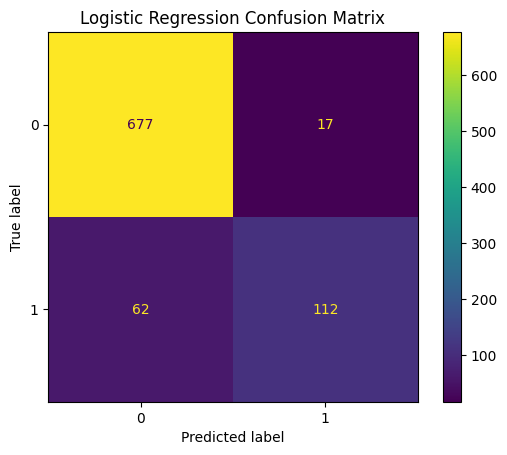

In [60]:
#confusin matrix
ConfusionMatrixDisplay.from_estimator(logis_pipeline, X_test, y_test)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

## MODEL 2

In [61]:
#decision tree model
param_grid = {"dt_model__max_depth": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}